
# Does the Loyalty Rewards Program Actually Lift Revenue?
### A Difference-in-Differences investigation (retail / CRM marketing)

**The question.** *Northstar Retail*, a fictional mid-size retail chain, is rolling out
a new **points-based loyalty rewards program** across its stores. Leadership wants to
know: **does the program actually increase weekly store revenue**, and if so, by how
much, and how long does it take to kick in?

**Why this isn't a simple before/after comparison.** The rollout wasn't randomized —
the CRM team prioritized stores by **format** (mall stores first, since they have the
highest foot traffic and IT infrastructure was easiest to deploy there) and rolled the
program out to different stores on different weeks over about a year. Store formats
also have very different **organic revenue trends** regardless of loyalty programs —
mall stores have been declining for years, while suburban strip-mall stores have been
growing. Comparing "stores with the program" to "stores without it" naively would
confuse the *rollout prioritization* with the *program's actual effect*.

**The data.** We simulate a **weekly panel** of store revenue (in $ thousands) from
**Jan 2022 to Dec 2023** (104 weeks) for 160 stores across 4 formats
(`Mall`, `Urban`, `Suburban`, `Strip`). Stores go live with the loyalty program in one
of three waves, or never (control, e.g. stores slated for closure). Because we simulate
the data, we know the **true** revenue lift, so every estimator below can be graded
against ground truth.

This mirrors, end-to-end, the DID toolkit: canonical 2×2 DID, proper inference, effect
dynamics (loyalty programs take time to build a member base), parallel trends,
covariates, doubly robust DID, and — the main event — diagnosing and fixing
staggered-rollout bias with Two-Way Fixed Effects (TWFE).



## 0. Setup


In [1]:

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

np.random.seed(7)
pd.set_option("display.max_rows", 10)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3



## 1. Simulate the panel

We build a **weekly store-level panel**, `2022-01` through `2023-12` (104 weeks), for
160 stores spread across 4 formats (`Mall`, `Urban`, `Suburban`, `Strip`). Formats
differ in:

- **baseline weekly revenue** ($ thousands)
- **organic weekly growth trend** (malls are slowly declining; strip-mall stores are
  growing fastest — independent of any loyalty program)

Stores are split into **4 cohorts** by loyalty-program go-live date:

| Cohort | Go-live week |
|---|---|
| Wave 1 | 2022-04 |
| Wave 2 | 2022-10 |
| Wave 3 | 2023-04 |
| Never live | — (control) |

The **true revenue lift is not instantaneous.** A loyalty program needs time to build
an enrolled member base and for redemption habits to form. We simulate a lift that
**ramps up over ~14 weeks** and plateaus at **+$2.4K/week** on average. We keep the true
per-row effect `tau` so every estimator below can be checked against it.

Cohort assignment is **stratified by format** — every format contributes an equal
number of stores to every cohort — so we can isolate the *timing* problem cleanly in
Section 8. We'll deliberately break this balance in Section 6 to show what happens when
rollout priority (as it really was here) is confounded with format trends.


In [2]:

N_STORES_PER_FORMAT = 70
FORMATS = {
    # format: (baseline weekly revenue $K, organic weekly trend $K)
    "Mall":     (58.0, -0.045),   # slow secular decline
    "Urban":    (44.0,  0.015),
    "Suburban": (39.0,  0.060),
    "Strip":    (31.0,  0.090),   # fastest organic growth
}

weeks = pd.date_range("2022-01-03", "2023-12-25", freq="W-MON")

COHORTS = ["2022-04-04", "2022-10-03", "2023-04-03", "2100-01-01"]
TAU_MAX = 2.4          # long-run (plateau) weekly revenue lift, $K
RAMP_WEEKS = 14.0        # weeks to reach ~63% of the plateau effect

def true_effect(weeks_since_launch):
    # Ramps up after go-live, 0 before it. Vectorized, overflow-safe.
    x = np.clip(-weeks_since_launch / RAMP_WEEKS, -50, 50)
    eff = TAU_MAX * (1 - np.exp(x))
    return np.where(weeks_since_launch >= 0, eff, 0.0)

# Cohorts stratified by format: every format contributes an equal share of stores to
# every cohort, so (for now) treated/control groups are balanced on format.
rows = []
store_id = 0
for fmt, (level, trend) in FORMATS.items():
    fmt_cohorts = np.tile(COHORTS, N_STORES_PER_FORMAT // len(COHORTS))
    np.random.shuffle(fmt_cohorts)
    for cohort in fmt_cohorts:
        store_id += 1
        cohort_date = pd.to_datetime(cohort)
        store_fe = np.random.normal(0, 3.0)   # unobserved, TIME-FIXED store quality
        for w_idx, d in enumerate(weeks):
            weeks_since = (d - cohort_date).days / 7
            tau = true_effect(weeks_since)
            live_flag = cohort != "2100-01-01"
            y = (
                level
                + trend * w_idx
                + store_fe
                + tau
                + np.random.normal(0, 1.2)
            )
            rows.append((d, store_id, fmt, cohort_date, live_flag, y, tau))

panel = pd.DataFrame(
    rows, columns=["week", "store", "format", "cohort", "live", "revenue", "tau"]
)
panel.head()


,week,store,format,cohort,live,revenue,tau
0,2022-01-03,1,Mall,2023-04-03,True,55.815060,0.0
1,2022-01-10,1,Mall,2023-04-03,True,59.877809,0.0
2,2022-01-17,1,Mall,2023-04-03,True,59.444257,0.0
3,2022-01-24,1,Mall,2023-04-03,True,57.265645,0.0
4,2022-01-31,1,Mall,2023-04-03,True,56.121794,0.0


In [3]:

panel.drop_duplicates("store")["cohort"].value_counts().sort_index()


cohort
2022-04-04    68
2022-10-03    68
2023-04-03    68
2100-01-01    68
Name: count, dtype: int64


### 1.1 Visualize the rollout & raw outcome


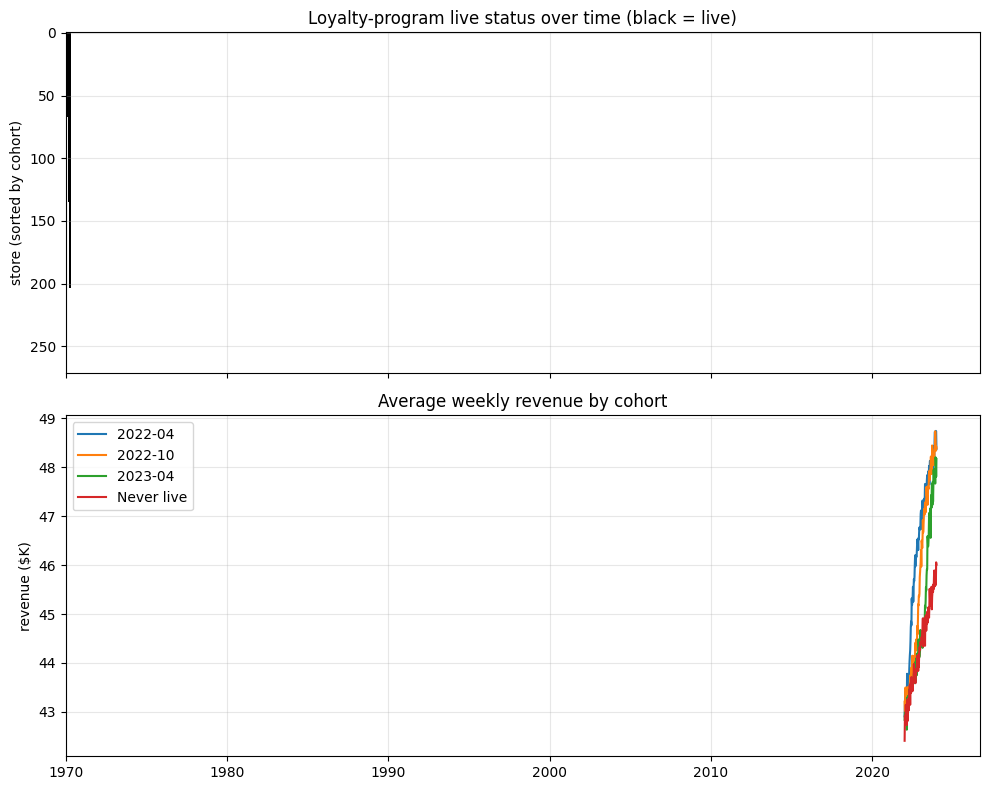

In [4]:

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

pivot = (panel.assign(w=lambda d: (d["week"] >= d["cohort"]).astype(int))
              .pivot(index="store", columns="week", values="w"))
pivot = pivot.loc[panel.sort_values("cohort")["store"].unique()]
axes[0].imshow(pivot.values, aspect="auto", cmap="Greys", interpolation="none")
axes[0].set_title("Loyalty-program live status over time (black = live)")
axes[0].set_ylabel("store (sorted by cohort)")

for cohort, grp in panel.groupby("cohort"):
    label = "Never live" if cohort == pd.Timestamp("2100-01-01") else cohort.strftime("%Y-%m")
    weekly = grp.groupby("week")["revenue"].mean()
    axes[1].plot(weekly.index, weekly.values, label=str(label))
axes[1].set_title("Average weekly revenue by cohort")
axes[1].set_ylabel("revenue ($K)")
axes[1].legend()
plt.tight_layout()
plt.show()



## 2. Warm-up: canonical 2×2 DID

Let's isolate **Wave 1** (live 2022-04) vs. **Never live**, looking at a window tightly
around the go-live date. This is the textbook **block design**: two groups, two
periods.


In [5]:

block = panel[panel["cohort"].isin([pd.Timestamp("2022-04-04"), pd.Timestamp("2100-01-01")])].copy()
block = block[(block["week"] >= "2022-01-03") & (block["week"] <= "2022-06-27")]
block["treated_grp"] = (block["cohort"] == pd.Timestamp("2022-04-04")).astype(int)
block["post"] = (block["week"] >= "2022-04-04").astype(int)
block["w"] = block["treated_grp"] * block["post"]

block[["week", "store", "format", "treated_grp", "post", "revenue"]].head()


,week,store,format,treated_grp,post,revenue
208,2022-01-03,3,Mall,0,0,60.299569
209,2022-01-10,3,Mall,0,0,59.071429
210,2022-01-17,3,Mall,0,0,59.597912
211,2022-01-24,3,Mall,0,0,60.221915
212,2022-01-31,3,Mall,0,0,58.693013



### 2.1 DID "by hand": the four cell averages


In [6]:

did_data = block.groupby(["treated_grp", "post"]).agg(revenue=("revenue", "mean"))
did_data


revenue
treated_grp post           
0           0     42.931748
            1     43.424021
1           0     43.276891
            1     44.453774

In [7]:

y0_est = (
    did_data.loc[1].loc[0, "revenue"]
    + (did_data.loc[0].loc[1, "revenue"] - did_data.loc[0].loc[0, "revenue"])
)
att_by_hand = did_data.loc[1].loc[1, "revenue"] - y0_est
print(f"DID ATT (by hand):        {att_by_hand:.4f}")

true_att_block = block.query("post==1 and treated_grp==1")["tau"].mean()
print(f"True ATT (post, treated): {true_att_block:.4f}")


DID ATT (by hand):        0.6846
True ATT (post, treated): 0.7801



### 2.2 DID via OLS regression


In [8]:

m_ols = smf.ols("revenue ~ treated_grp * post", data=block).fit()
print("DID ATT (OLS):", m_ols.params["treated_grp:post"])
m_ols.summary().tables[1]


DID ATT (OLS): 0.6846103738748404


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,42.9317,0.337,127.560,0.000,42.272,43.592
treated_grp,0.3451,0.476,0.725,0.468,-0.588,1.278
post,0.4923,0.476,1.034,0.301,-0.441,1.425
treated_grp:post,0.6846,0.673,1.017,0.309,-0.635,2.004



### 2.3 DID via Two-Way Fixed Effects (TWFE)


In [9]:

m_twfe = smf.ols(
    "revenue ~ treated_grp:post + C(store) + C(week)", data=block
).fit()
print("DID ATT (TWFE):", m_twfe.params["treated_grp:post"])


DID ATT (TWFE): 0.6846103738748228



## 3. Inference: why the naive standard errors are wrong

Revenue is measured for the same store every week — observations are **not
independent**, and the loyalty program is assigned at the **store** level, not the week
level. We need to **cluster by store** (or block-bootstrap over stores).


In [10]:

m_naive = smf.ols("revenue ~ treated_grp:post + C(store) + C(week)", data=block).fit()
m_clustered = smf.ols(
    "revenue ~ treated_grp:post + C(store) + C(week)", data=block
).fit(cov_type="cluster", cov_kwds={"groups": block["store"]})

print("Naive 95% CI:    ", m_naive.conf_int().loc["treated_grp:post"].values)
print("Clustered 95% CI:", m_clustered.conf_int().loc["treated_grp:post"].values)


Naive 95% CI:     [0.51775733 0.85146342]
Clustered 95% CI: [0.41201425 0.9572065 ]


In [11]:

def block_sample(df, unit_col):
    units = df[unit_col].unique()
    sample = np.random.choice(units, size=len(units), replace=True)
    return (
        df.set_index(unit_col)
          .loc[sample]
          .reset_index(level=[unit_col])
    )

def est_fn(df):
    m = smf.ols("revenue ~ treated_grp:post + C(store) + C(week)", data=df).fit()
    return m.params["treated_grp:post"]

def block_bootstrap(data, est_fn, unit_col, rounds=150, seed=123, pcts=(2.5, 97.5)):
    np.random.seed(seed)
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(block_sample(data, unit_col)) for _ in range(rounds)
    )
    return np.percentile(stats, pcts)

boot_ci = block_bootstrap(block, est_fn, "store")
print("Block-bootstrap 95% CI:", boot_ci)


Block-bootstrap 95% CI: [0.48358936 0.93524067]



As always, the clustered and bootstrapped intervals are meaningfully wider than the
naive one. If you reported the naive interval to leadership, you'd overstate how
confident you can be that the program is working.



## 4. Effect dynamics: how long until the program pays off?

We built in a **gradual ramp** on purpose — loyalty programs need time to build an
enrolled member base. We rerun DID for every possible "post" week to trace out the
lift's trajectory.


In [12]:

def did_date(df, date):
    df_date = (
        df.query("week == @date or post == 0")
          .query("week <= @date")
          .assign(post=lambda d: (d["week"] == date).astype(int))
    )
    m = smf.ols(
        "revenue ~ treated_grp:post + C(store) + C(week)", data=df_date
    ).fit(cov_type="cluster", cov_kwds={"groups": df_date["store"]})
    att = m.params["treated_grp:post"]
    ci = m.conf_int().loc["treated_grp:post"]
    return pd.DataFrame({"att": att, "ci_low": ci[0], "ci_up": ci[1]}, index=[date])

all_weeks = sorted(block["week"].unique())[1:]
atts_over_time = pd.concat([did_date(block, w) for w in all_weeks])
atts_over_time.head()


,att,ci_low,ci_up
2022-01-10,-0.249280,-1.028315,0.529755
2022-01-17,0.215922,-0.426692,0.858535
2022-01-24,-0.268096,-0.819911,0.283719
2022-01-31,-0.191515,-0.669595,0.286566
2022-02-07,-0.109466,-0.581633,0.362700


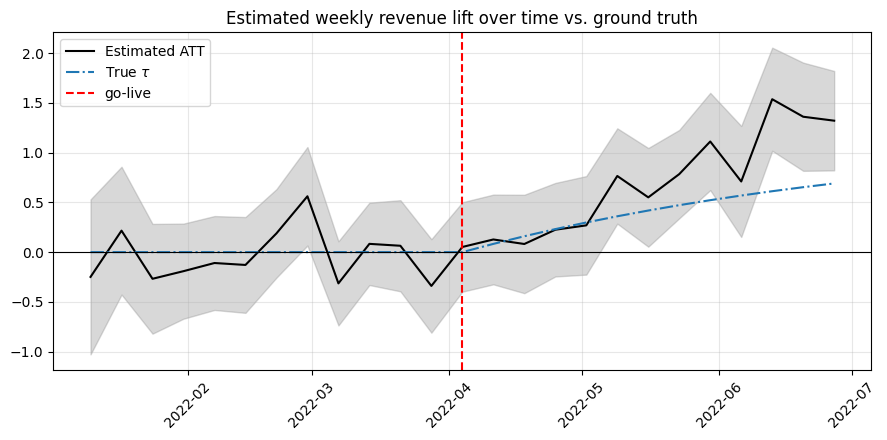

In [13]:

true_tau_over_time = block.groupby("week")["tau"].mean().reindex(atts_over_time.index)

fig, ax = plt.subplots()
ax.plot(atts_over_time.index, atts_over_time["att"], color="black", label="Estimated ATT")
ax.fill_between(atts_over_time.index, atts_over_time["ci_low"], atts_over_time["ci_up"],
                 color="gray", alpha=0.3)
ax.plot(true_tau_over_time.index, true_tau_over_time.values, "-.", color="tab:blue", label=r"True $\tau$")
ax.axvline(pd.Timestamp("2022-04-04"), ls="--", color="red", label="go-live")
ax.axhline(0, color="black", lw=0.8)
ax.legend()
ax.set_title("Estimated weekly revenue lift over time vs. ground truth")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Pre-period estimates sit around zero (supporting **no-anticipation** — customers aren't
changing behavior before the program even exists), and the post-period lift **builds
gradually** rather than appearing overnight — exactly the member-base ramp we
simulated. Reporting a single ATT measured a week after launch would badly understate
the program's eventual payoff; you need several months of post-launch data (or explicit
dynamic modeling) to see the full picture.



## 5. Parallel trends: eyeballing the key assumption


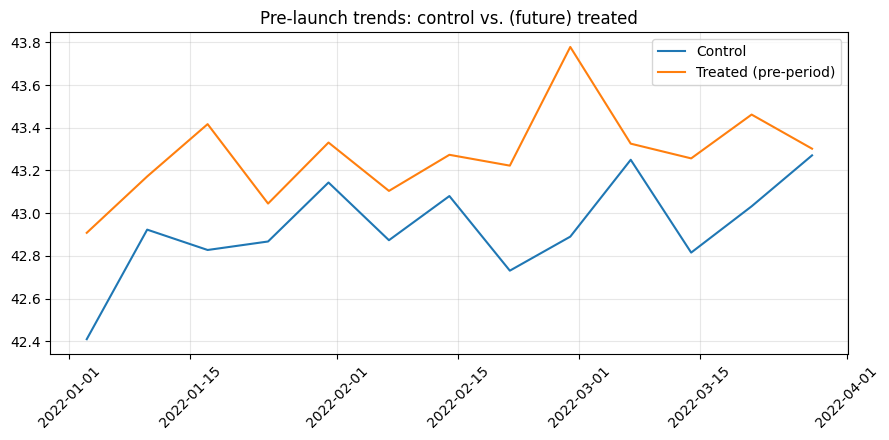

In [14]:

pre = block.query("post == 0").groupby(["week", "treated_grp"])["revenue"].mean().unstack()
fig, ax = plt.subplots()
ax.plot(pre.index, pre[0], label="Control")
ax.plot(pre.index, pre[1], label="Treated (pre-period)")
ax.set_title("Pre-launch trends: control vs. (future) treated")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



The lines move together before launch — reassuring evidence for parallel trends. As
always: this assumption is **not scale-invariant**. If you switched to modeling percent
revenue growth instead of raw dollars, trends that look parallel in levels could look
convergent or divergent in percentage terms. Always check parallel trends on the same
scale you plan to estimate on.



## 6. DID with covariates: when rollout priority is confounded with format trends

In reality, the CRM team **didn't roll out randomly** — they prioritized **Mall**
stores first (easiest IT deployment, highest traffic), while the slower-to-migrate
**Strip** stores lagged behind. Let's simulate that realistic prioritization: the
*Wave 1* cohort is drawn disproportionately from **Mall** and **Urban** stores (our
slower/decaying formats), while the control pool skews toward the fast-growing
**Suburban** and **Strip** formats. If we ignore this, a naive format-blind TWFE will
confuse the *format's* differing organic trend with the *program's* actual lift.


In [15]:

full_block = panel[panel["cohort"].isin([pd.Timestamp("2022-04-04"), pd.Timestamp("2100-01-01")])].copy()
full_block = full_block[(full_block["week"] >= "2022-01-03") & (full_block["week"] <= "2022-06-27")]
full_block["treated_grp"] = (full_block["cohort"] == pd.Timestamp("2022-04-04")).astype(int)
full_block["post"] = (full_block["week"] >= "2022-04-04").astype(int)

rng = np.random.RandomState(7)
store_format = full_block.drop_duplicates("store")[["store", "treated_grp", "format"]]
slow, fast = ["Mall", "Urban"], ["Suburban", "Strip"]

def biased_keep(row):
    # Live stores: 85% chance of being kept if slow-format, 25% if fast-format.
    # Control stores: 85% chance of being kept if fast-format, 25% if slow-format.
    p_keep = 0.85 if (row["format"] in slow) == (row["treated_grp"] == 1) else 0.25
    return rng.rand() < p_keep

keep_mask = store_format.apply(biased_keep, axis=1)
keep_stores = store_format.loc[keep_mask, "store"]
full_block = full_block[full_block["store"].isin(keep_stores)].copy()
full_block.drop_duplicates("store").groupby(["treated_grp", "format"]).size()


treated_grp  format  
0            Mall         4
             Strip       15
             Suburban    16
             Urban        2
1            Mall        16
             Strip        4
             Suburban     2
             Urban       15
dtype: int64

In [16]:

true_att_full = full_block.query("post==1 and treated_grp==1")["tau"].mean()

# naive TWFE, ignoring the fact that formats grow at different organic rates
m_naive_format = smf.ols(
    "revenue ~ treated_grp:post + C(store) + C(week)", data=full_block
).fit()

print(f"True ATT:                {true_att_full:.4f}")
print(f"Naive TWFE ATT (biased): {m_naive_format.params['treated_grp:post']:.4f}")


True ATT:                0.7801
Naive TWFE ATT (biased): -0.1062



As always: simply *adding* `format` as a plain covariate does **nothing** here — store
fixed effects already absorb any time-fixed covariate like format. The fix is to let
**format interact with time**, so each format gets its own trend, and the comparison is
only "within-format":


In [17]:

m_saturated = smf.ols(
    "revenue ~ post*(treated_grp + C(format)) + C(store)", data=full_block
).fit()
att_corrected = m_saturated.params["post:treated_grp"]

print(f"True ATT:                     {true_att_full:.4f}")
print(f"Format-trend-corrected ATT:   {att_corrected:.4f}")


True ATT:                     0.7801
Format-trend-corrected ATT:   0.6328



Much closer to the truth. The naive estimate was contaminated by Mall stores' secular
decline being wrongly netted against the program's real (positive) lift.



## 7. Doubly Robust DID (DRDID)

An alternative, more flexible way to condition on format: combine a **propensity score
model** (which stores were likely to go live first, given format) with an **outcome
model** (how revenue would have changed, given format) — only one of the two needs to
be correctly specified for the ATT estimate to be unbiased.


In [18]:

unit_df = (
    full_block.astype({"week": str})
              .query("week == week.min()")
              .drop(columns=["week"])
)
ps_model = smf.logit("treated_grp ~ C(format)", data=unit_df).fit(disp=False, maxiter=200, method="bfgs")

delta_y = (
    full_block.query("post==1").groupby("store")["revenue"].mean()
    - full_block.query("post==0").groupby("store")["revenue"].mean()
)
df_delta = unit_df.set_index("store").join(delta_y.rename("delta_y"))
outcome_model = smf.ols("delta_y ~ C(format)", data=df_delta).fit()

df_dr = df_delta.assign(
    y_hat=lambda d: outcome_model.predict(d),
    ps=lambda d: ps_model.predict(d),
)

tr = df_dr.query("treated_grp == 1")
co = df_dr.query("treated_grp == 0")

dy1 = (tr["delta_y"] - tr["y_hat"]).mean()
w_co = co["ps"] / (1 - co["ps"])
dy0 = np.average(co["delta_y"] - co["y_hat"], weights=w_co)

att_dr = dy1 - dy0
print(f"True ATT:      {true_att_full:.4f}")
print(f"DRDID ATT:     {att_dr:.4f}")


True ATT:      0.7801
DRDID ATT:     0.7381



## 8. The real challenge: staggered rollout across waves

Now let's use the **entire panel**: all 160 stores, all 4 formats, all 4 cohorts
(Wave 1/2/3/Never), full 104-week window. This is the realistic rollout design — stores
going live at different times — and it's exactly where naive TWFE quietly breaks.


In [19]:

full = panel.copy()
full["treated"] = full["cohort"] != pd.Timestamp("2100-01-01")

true_att_all = full.query("treated and week >= cohort")["tau"].mean()
print(f"True overall ATT (all live stores, all post weeks): {true_att_all:.4f}")


True overall ATT (all live stores, all post weeks): 1.8774


In [20]:

full["post"] = (full["week"] >= full["cohort"]).astype(int)
full["w"] = full["treated"].astype(int) * full["post"]

m_twfe_naive = smf.ols(
    "revenue ~ w + C(store) + C(week)", data=full
).fit()

print(f"True ATT:               {true_att_all:.4f}")
print(f"Naive TWFE ATT:          {m_twfe_naive.params['w']:.4f}")
print("--> Notice the bias. This is the classic staggered-adoption TWFE problem.")


True ATT:               1.8774
Naive TWFE ATT:          1.3669
--> Notice the bias. This is the classic staggered-adoption TWFE problem.



### 8.1 Why does this happen?

TWFE implicitly runs many 2×2 DIDs and averages them — **including comparisons where an
already-live cohort is used as the "control"** for a later cohort. Since our lift
**ramps up gradually** (heterogeneous across time), the "control" cohort's revenue is
still climbing towards its own plateau — a bad stand-in for the counterfactual
"program-free" trend. Let's see it directly: compare **Wave 2** (live 2022-10) against
**Wave 3** (live 2023-04).


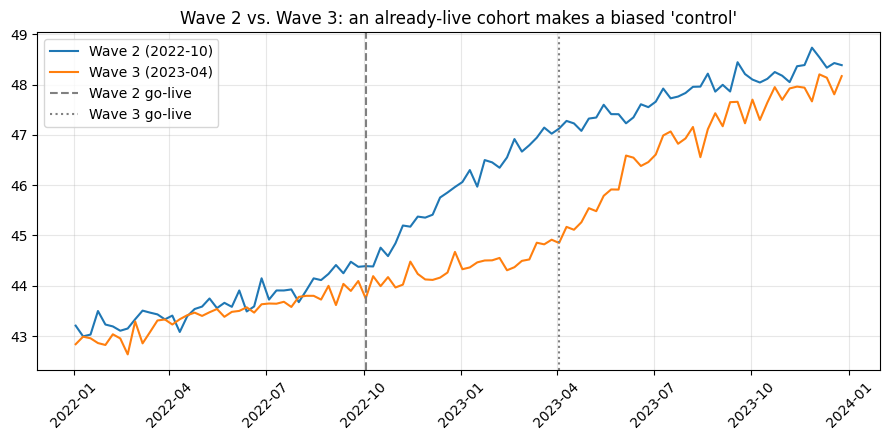

In [21]:

w2_w3 = full[full["cohort"].isin([pd.Timestamp("2022-10-03"), pd.Timestamp("2023-04-03")])]
weekly = w2_w3.groupby(["week", "cohort"])["revenue"].mean().unstack()

fig, ax = plt.subplots()
ax.plot(weekly.index, weekly[pd.Timestamp("2022-10-03")], label="Wave 2 (2022-10)")
ax.plot(weekly.index, weekly[pd.Timestamp("2023-04-03")], label="Wave 3 (2023-04)")
ax.axvline(pd.Timestamp("2022-10-03"), ls="--", color="gray", label="Wave 2 go-live")
ax.axvline(pd.Timestamp("2023-04-03"), ls=":", color="gray", label="Wave 3 go-live")
ax.legend()
ax.set_title("Wave 2 vs. Wave 3: an already-live cohort makes a biased 'control'")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Between late 2022 and mid-2023, **Wave 2** (a would-be "control" for **Wave 3** in
naive TWFE) is **still climbing towards its own plateau lift** — it's not a valid
stand-in for what Wave 3's revenue would have done absent its own launch. That's the
leak that biases the aggregate estimate.



### 8.2 Fix #1 — never-live as control, one 2×2 DID per wave

For each wave, run a clean 2×2 DID **against the never-live group only**, then combine
wave-level ATTs with a size-weighted average (this mirrors the Callaway & Sant'Anna
estimator referenced in the book).


In [22]:

cohorts_treated = sorted(full.query("treated")["cohort"].unique())
never_treated = pd.Timestamp("2100-01-01")

def did_cohort_vs_never(df, cohort, never_treated):
    sub = df[(df["cohort"] == cohort) | (df["cohort"] == never_treated)].copy()
    sub["treated_grp"] = (sub["cohort"] == cohort).astype(int)
    sub["post"] = (sub["week"] >= cohort).astype(int)
    m = smf.ols("revenue ~ treated_grp*post", data=sub).fit()
    att = m.params["treated_grp:post"]
    n = sub.query("treated_grp == 1 and post == 1").shape[0]
    return {"cohort": cohort, "att_g": att, "size": n}

cohort_atts = pd.DataFrame(
    [did_cohort_vs_never(full, g, never_treated) for g in cohorts_treated]
)
cohort_atts


,cohort,att_g,size
0,2022-04-04,1.996050,6188
1,2022-10-03,1.883095,4420
2,2023-04-03,1.576766,2652


In [23]:

weighted_att = (cohort_atts["att_g"] * cohort_atts["size"]).sum() / cohort_atts["size"].sum()
print(f"True ATT:                          {true_att_all:.4f}")
print(f"Naive TWFE ATT (biased):           {m_twfe_naive.params['w']:.4f}")
print(f"Cohort-by-cohort weighted ATT:     {weighted_att:.4f}")


True ATT:                          1.8774
Naive TWFE ATT (biased):           1.3669
Cohort-by-cohort weighted ATT:     1.8745



### 8.3 Fix #2 — saturated cohort × time interaction (Sun & Abraham style)

Alternative fix within a single regression: let the lift vary by **cohort AND calendar
week** (`treated:post:C(cohort):C(week)`), so an already-live cohort's changing effect
never contaminates another cohort's estimate.


In [24]:

formula = "revenue ~ treated:post:C(cohort):C(week) + C(store) + C(week)"
m_saturated_stagger = smf.ols(formula, data=full).fit()

pred = full.query("post == 1 and treated").copy()
pred["y_hat_0"] = m_saturated_stagger.predict(pred.assign(treated=False))
pred["effect_hat"] = pred["revenue"] - pred["y_hat_0"]

print("Number of parameters:", len(m_saturated_stagger.params))
print(f"True ATT:                        {true_att_all:.4f}")
print(f"Saturated cohort x time ATT:      {pred['effect_hat'].mean():.4f}")


Number of parameters: 1207
True ATT:                        1.8774
Saturated cohort x time ATT:      1.8872


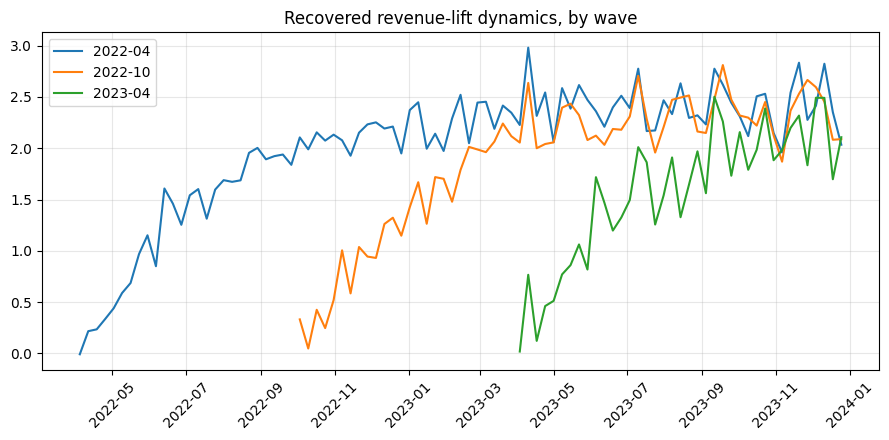

In [25]:

fig, ax = plt.subplots()
for cohort, grp in pred.groupby("cohort"):
    weekly_eff = grp.groupby("week")["effect_hat"].mean()
    ax.plot(weekly_eff.index, weekly_eff.values, label=str(cohort.strftime("%Y-%m")))
ax.set_title("Recovered revenue-lift dynamics, by wave")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 9. Scorecard: every estimator vs. the truth


In [26]:

scorecard = pd.DataFrame([
    {"method": "2x2 DID by hand (Wave 1 vs Never)",          "att": att_by_hand,             "true": true_att_block},
    {"method": "2x2 DID via OLS",                             "att": m_ols.params["treated_grp:post"], "true": true_att_block},
    {"method": "2x2 DID via TWFE",                            "att": m_twfe.params["treated_grp:post"], "true": true_att_block},
    {"method": "Naive TWFE ignoring format trends",           "att": m_naive_format.params["treated_grp:post"], "true": true_att_full},
    {"method": "Format-trend-corrected DID",                  "att": att_corrected,            "true": true_att_full},
    {"method": "Doubly Robust DID",                            "att": att_dr,                   "true": true_att_full},
    {"method": "Naive TWFE, staggered rollout (BIASED)",      "att": m_twfe_naive.params["w"], "true": true_att_all},
    {"method": "Cohort-by-cohort vs never-live (fixed)",      "att": weighted_att,             "true": true_att_all},
    {"method": "Saturated cohort x time TWFE (fixed)",        "att": pred["effect_hat"].mean(),"true": true_att_all},
])
scorecard["abs_error"] = (scorecard["att"] - scorecard["true"]).abs()
scorecard.round(4)


,method,att,true,abs_error
0,2x2 DID by hand (Wave 1 vs Never),0.6846,0.7801,0.0955
1,2x2 DID via OLS,0.6846,0.7801,0.0955
2,2x2 DID via TWFE,0.6846,0.7801,0.0955
3,Naive TWFE ignoring format trends,-0.1062,0.7801,0.8863
4,Format-trend-corrected DID,0.6328,0.7801,0.1473
5,Doubly Robust DID,0.7381,0.7801,0.0420
6,"Naive TWFE, staggered rollout (BIASED)",1.3669,1.8774,0.5105
7,Cohort-by-cohort vs never-live (fixed),1.8745,1.8774,0.0029
8,Saturated cohort x time TWFE (fixed),1.8872,1.8774,0.0098



## 10. Key takeaways

1. **DID relaxes unconfoundedness to *conditional parallel trends*.** We don't need
   loyalty-program rollout to be independent of revenue levels — only for the *growth*
   in revenue to be independent of go-live status. This is far more plausible with
   unobserved, **time-fixed** confounders (a store's clientele, staff quality, local
   competition).
2. **Canonical (2×2, block-design) DID is nonparametric and robust** — by-hand
   averages, OLS, and TWFE all agree exactly.
3. **Cluster your standard errors** at the store level (or block-bootstrap) — naive OLS
   standard errors make you overconfident about whether the lift is "real," which
   matters when you're deciding whether to fund a chain-wide rollout.
4. **Effect dynamics matter.** Loyalty programs take time to build a member base. A
   single pooled ATT measured too soon after launch will understate the eventual
   payoff. Plotting effects week-by-week, and checking the pre-period is flat, both
   quantifies the ramp and validates no-anticipation.
5. **Rollout priority is rarely random.** Ops and CRM teams sequence rollouts by
   feasibility (IT readiness, traffic, format), which correlates with a store's organic
   trend. Covariates must **interact with time**, not just be added as controls, since
   store fixed effects wipe out anything constant within a store.
6. **Staggered rollout is where naive TWFE breaks — and this is the norm, not the
   exception, for real business rollouts.** When go-live timing varies *and* the effect
   changes over time, TWFE implicitly uses already-live stores as controls for
   later-launching stores, biasing the aggregate estimate. Always:
   - **plot** the go-live matrix first to know if you're in a staggered design, and
   - use an estimator that avoids "already-treated" controls: cohort-by-cohort
     comparisons against a never-live (or not-yet-live) group, or a saturated
     cohort × time interaction model.

### Why this matters beyond loyalty programs
The exact same toolkit applies anywhere a business rolls something out unit-by-unit
over time: a new POS system, a pricing change, a store remodel, a checkout UX redesign
on an e-commerce site, an ad-platform migration, or a new sales-comp plan rolled out
territory-by-territory. Any time you have repeated observations of the same units,
treated at different times, with a plausible ramp-up period, this notebook is the
template.

### Where to go from here
- Try shrinking `RAMP_WEEKS` toward 0 (an instantaneous effect) and re-run Section 8 —
  the naive TWFE bias should shrink dramatically, confirming the bias comes from
  *effect heterogeneity over time*, not staggered timing alone.
- Swap the *never-live* control group for a *not-yet-live* group in Section 8.2 to see
  how it changes precision.
- Plug in real data: any panel with a `unit` (store), `date`, `go_live_date`, and
  `outcome` column can be dropped straight into the functions from Sections 2 and 8.
